In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('world-happiness-report.csv')

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Overview:
Shape: (158, 12)
Columns: ['Country', 'Region', 'Happiness Rank', 'Happiness Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

First few rows:
       Country          Region  Happiness Rank  Happiness Score  \
0  Switzerland  Western Europe               1            7.587   
1      Iceland  Western Europe               2            7.561   
2      Denmark  Western Europe               3            7.527   
3       Norway  Western Europe               4            7.522   
4       Canada   North America               5            7.427   

   Standard Error  Economy (GDP per Capita)   Family  \
0         0.03411                   1.39651  1.34951   
1         0.04884                   1.30232  1.40223   
2         0.03328                   1.32548  1.36058   
3         0.03880                   1.45900  1.33095   
4         0.03553                 

# Scatter Plot Visualizations


1. SCATTER PLOT VISUALIZATIONS


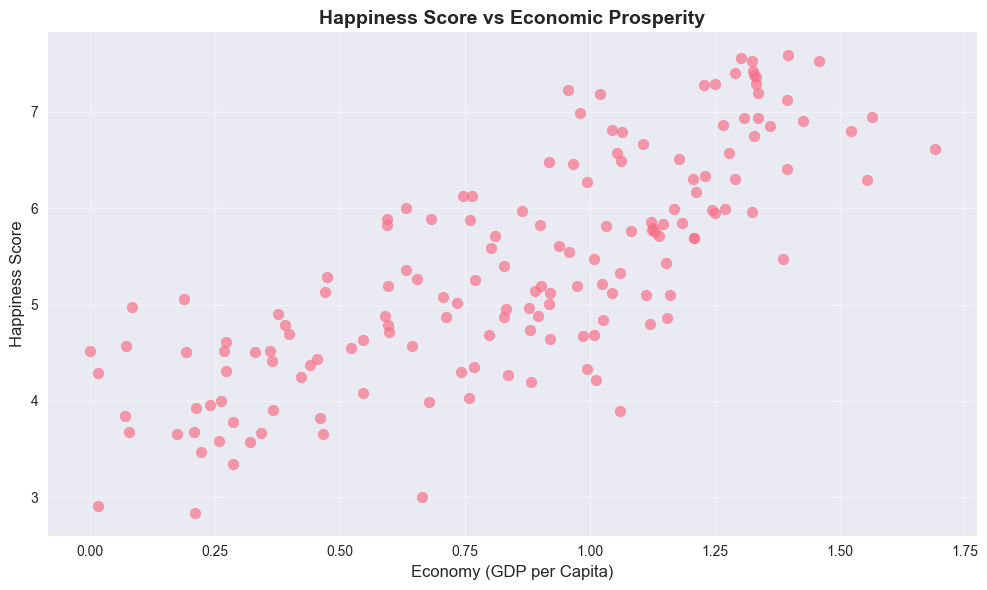


**Analysis - Basic Scatter Plot:**
This scatter plot reveals a strong positive correlation between economic prosperity (GDP per capita) 
and happiness scores. Countries with higher GDP per capita tend to have higher happiness scores, 
suggesting that economic development plays a significant role in national well-being.



In [2]:

# =============================================================================
# 1. SCATTER PLOT VISUALIZATIONS
# =============================================================================

print("\n" + "="*60)
print("1. SCATTER PLOT VISUALIZATIONS")
print("="*60)

# 1.1 Basic Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(df['Economy (GDP per Capita)'], df['Happiness Score'], alpha=0.7, s=60)
plt.xlabel('Economy (GDP per Capita)', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.title('Happiness Score vs Economic Prosperity', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
**Analysis - Basic Scatter Plot:**
This scatter plot reveals a strong positive correlation between economic prosperity (GDP per capita) 
and happiness scores. Countries with higher GDP per capita tend to have higher happiness scores, 
suggesting that economic development plays a significant role in national well-being.
""")

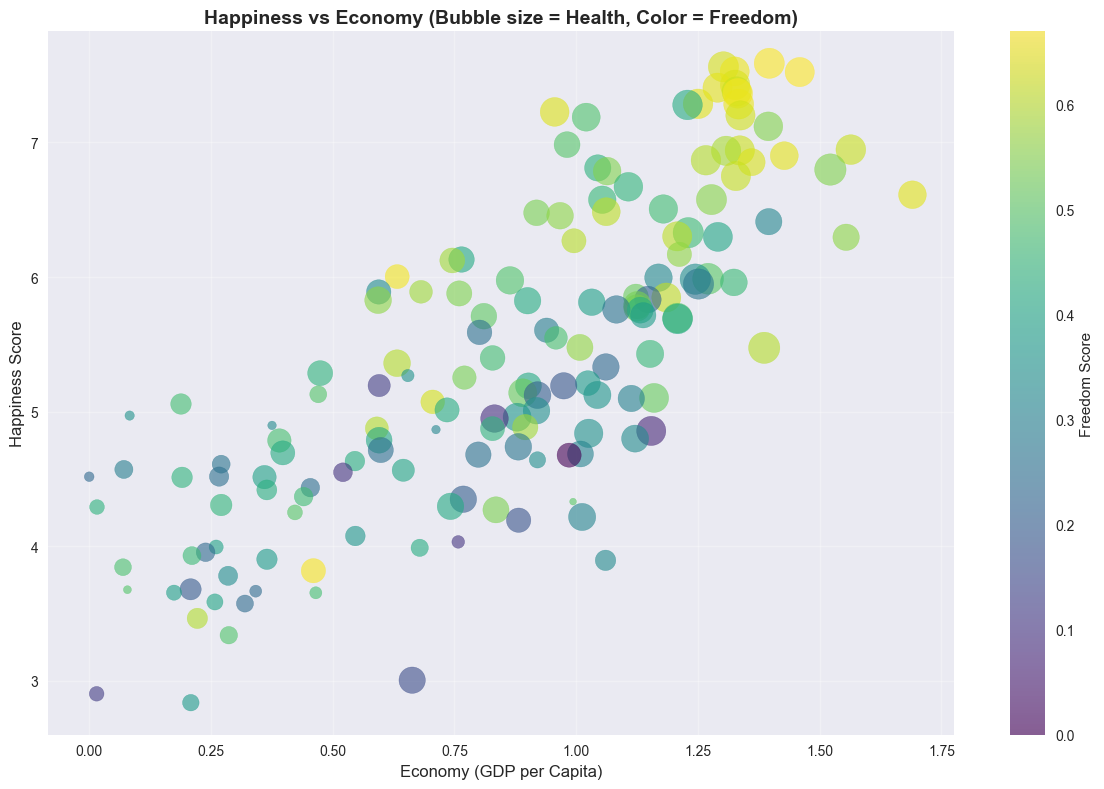


**Analysis - Bubble Chart:**
This multi-dimensional visualization shows that countries with larger bubbles (better health) 
and warmer colors (more freedom) tend to cluster in the upper-right region, indicating that 
health, freedom, and economic prosperity work together to create higher happiness levels.



In [3]:
# 1.2 Bubble Chart
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['Economy (GDP per Capita)'], df['Happiness Score'], 
                     s=df['Health (Life Expectancy)']*500, # Size based on health
                     c=df['Freedom'], # Color based on freedom
                     alpha=0.6, cmap='viridis')
plt.xlabel('Economy (GDP per Capita)', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.title('Happiness vs Economy (Bubble size = Health, Color = Freedom)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Freedom Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
**Analysis - Bubble Chart:**
This multi-dimensional visualization shows that countries with larger bubbles (better health) 
and warmer colors (more freedom) tend to cluster in the upper-right region, indicating that 
health, freedom, and economic prosperity work together to create higher happiness levels.
""")

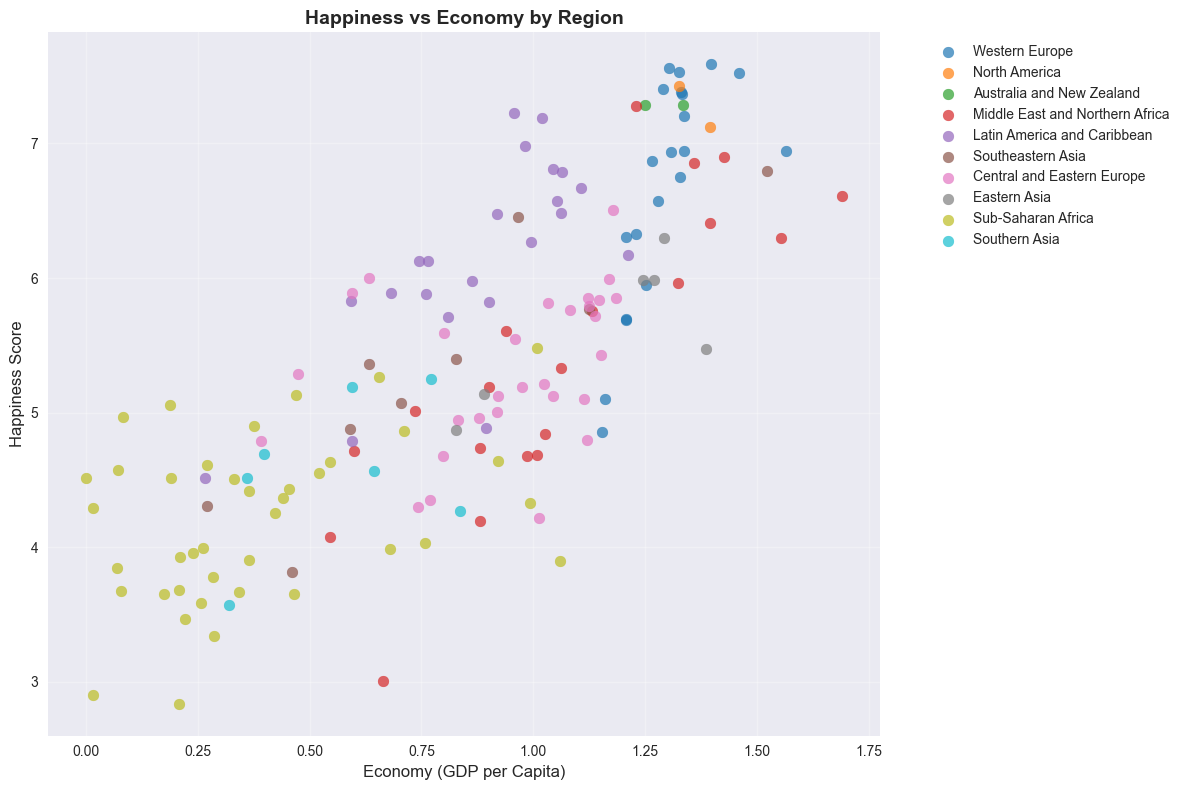


**Analysis - Grouped Scatter Plot:**
Regional patterns emerge clearly: Western European countries dominate the upper-right quadrant 
(high happiness and economy), while Sub-Saharan African countries cluster in the lower-left. 
This suggests regional factors beyond individual country characteristics influence happiness.



In [4]:

# 1.3 Grouped/Color-Coded Scatter Plot
plt.figure(figsize=(12, 8))
regions = df['Region'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(regions)))

for i, region in enumerate(regions):
    region_data = df[df['Region'] == region]
    plt.scatter(region_data['Economy (GDP per Capita)'], region_data['Happiness Score'],
               label=region, alpha=0.7, s=60, color=colors[i])

plt.xlabel('Economy (GDP per Capita)', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.title('Happiness vs Economy by Region', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
**Analysis - Grouped Scatter Plot:**
Regional patterns emerge clearly: Western European countries dominate the upper-right quadrant 
(high happiness and economy), while Sub-Saharan African countries cluster in the lower-left. 
This suggests regional factors beyond individual country characteristics influence happiness.
""")

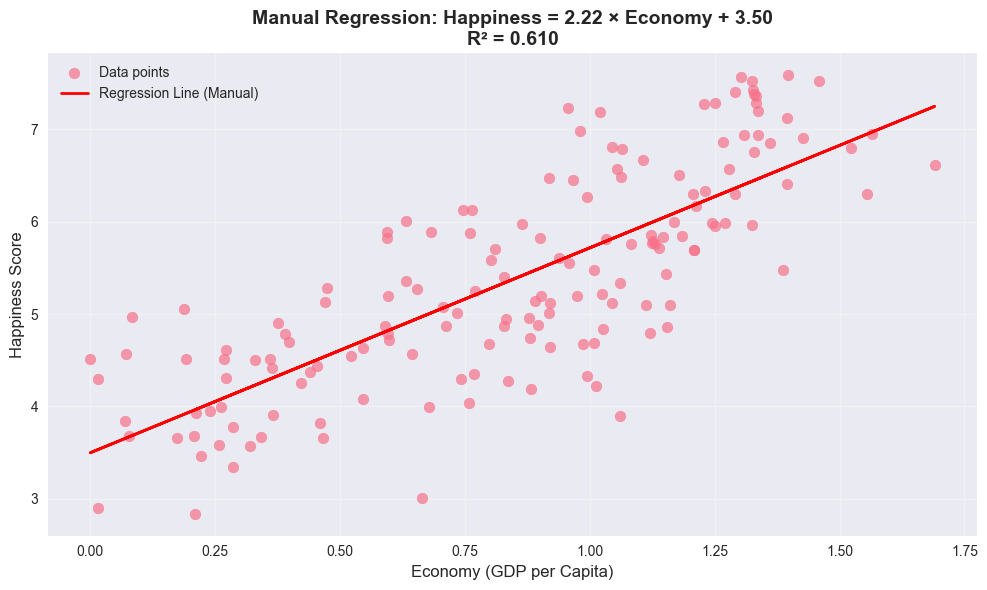


**Analysis - Manual Regression:**
Equation: Happiness Score = 2.22 × Economy + 3.50
R² = 0.610

For every 1-unit increase in GDP per capita, happiness score increases by 2.22 points.
The model explains 61.0% of the variance in happiness scores.



In [5]:

# 1.4 Regression Line (Manual Calculation)
x = df['Economy (GDP per Capita)'].values
y = df['Happiness Score'].values

# Remove any NaN values
mask = ~(np.isnan(x) | np.isnan(y))
x_clean = x[mask]
y_clean = y[mask]

# Manual least squares calculation
n = len(x_clean)
x_mean = np.mean(x_clean)
y_mean = np.mean(y_clean)

# Calculate slope (m) and intercept (b)
numerator = np.sum((x_clean - x_mean) * (y_clean - y_mean))
denominator = np.sum((x_clean - x_mean) ** 2)
slope = numerator / denominator
intercept = y_mean - slope * x_mean

# Calculate R-squared
y_pred = slope * x_clean + intercept
ss_res = np.sum((y_clean - y_pred) ** 2)
ss_tot = np.sum((y_clean - y_mean) ** 2)
r_squared = 1 - (ss_res / ss_tot)

plt.figure(figsize=(10, 6))
plt.scatter(x_clean, y_clean, alpha=0.7, s=60, label='Data points')
plt.plot(x_clean, y_pred, 'r-', linewidth=2, label=f'Regression Line (Manual)')
plt.xlabel('Economy (GDP per Capita)', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.title(f'Manual Regression: Happiness = {slope:.2f} × Economy + {intercept:.2f}\nR² = {r_squared:.3f}', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"""
**Analysis - Manual Regression:**
Equation: Happiness Score = {slope:.2f} × Economy + {intercept:.2f}
R² = {r_squared:.3f}

For every 1-unit increase in GDP per capita, happiness score increases by {slope:.2f} points.
The model explains {r_squared*100:.1f}% of the variance in happiness scores.
""")

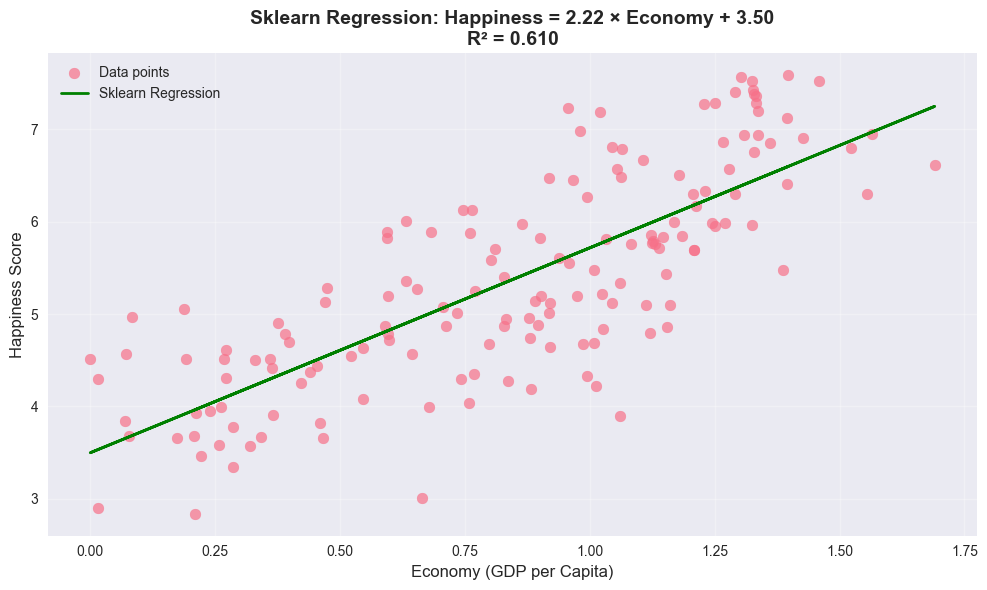


**Analysis - Sklearn Regression:**
Equation: Happiness Score = 2.22 × Economy + 3.50
R² = 0.610

**Prediction Example:** A country with GDP per capita = 1.0 would have 
predicted happiness score = 5.72



In [6]:

# 1.5 Regression Line using sklearn
model = LinearRegression()
X = df[['Economy (GDP per Capita)']].dropna()
y = df['Happiness Score'].dropna()

# Ensure same length
min_len = min(len(X), len(y))
X = X.iloc[:min_len]
y = y.iloc[:min_len]

model.fit(X, y)
y_pred_sklearn = model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.7, s=60, label='Data points')
plt.plot(X, y_pred_sklearn, 'g-', linewidth=2, label='Sklearn Regression')
plt.xlabel('Economy (GDP per Capita)', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.title(f'Sklearn Regression: Happiness = {model.coef_[0]:.2f} × Economy + {model.intercept_:.2f}\nR² = {model.score(X, y):.3f}', 
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Prediction example
sample_gdp = 1.0
predicted_happiness = model.predict([[sample_gdp]])[0]
print(f"""
**Analysis - Sklearn Regression:**
Equation: Happiness Score = {model.coef_[0]:.2f} × Economy + {model.intercept_:.2f}
R² = {model.score(X, y):.3f}

**Prediction Example:** A country with GDP per capita = {sample_gdp} would have 
predicted happiness score = {predicted_happiness:.2f}
""")

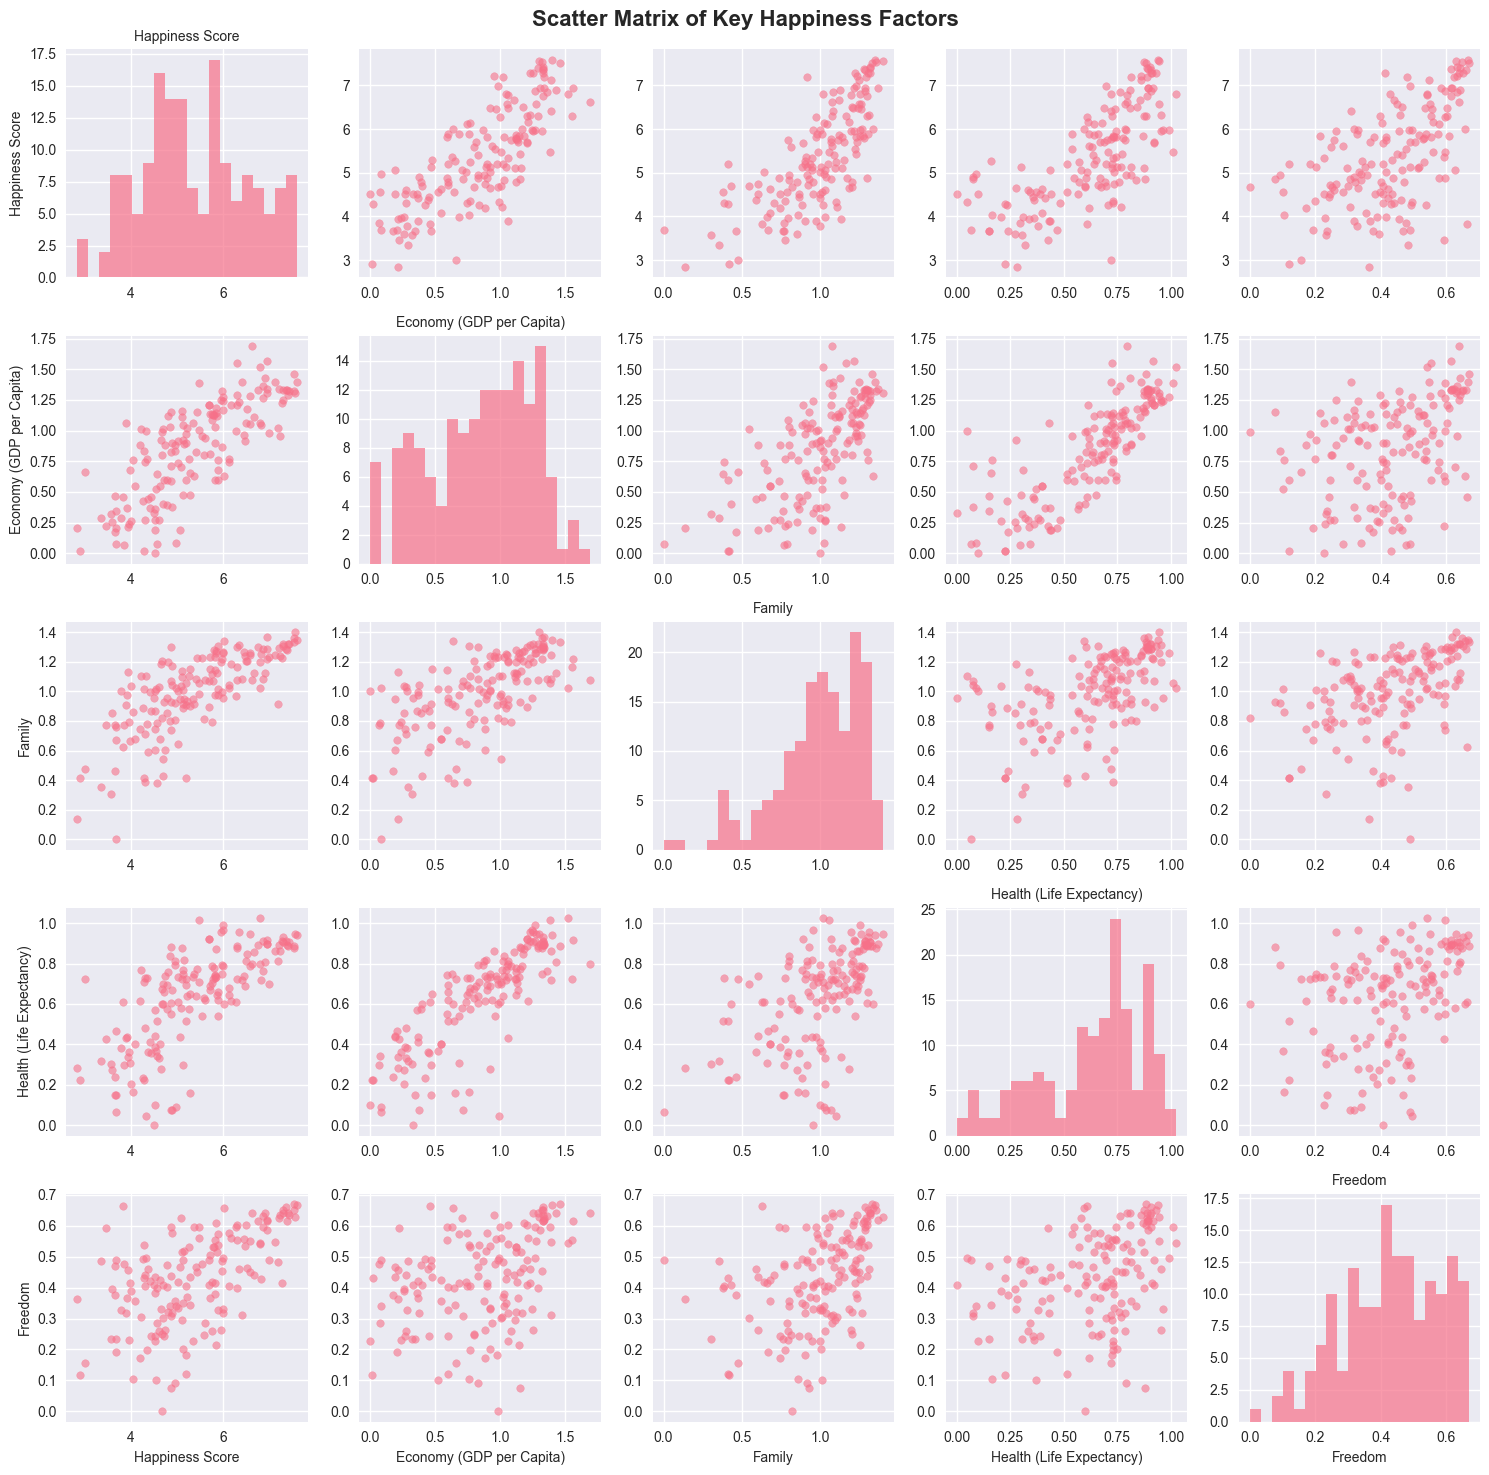


**Analysis - Scatter Matrix:**
The scatter matrix reveals strong positive correlations between most happiness factors. 
Economy, Family, Health, and Freedom all show positive relationships with Happiness Score, 
indicating these factors work synergistically to improve national well-being.



In [7]:

# 1.6 Scatter Matrix
numeric_cols = ['Happiness Score', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom']
scatter_data = df[numeric_cols].dropna()

fig, axes = plt.subplots(len(numeric_cols), len(numeric_cols), figsize=(15, 15))
fig.suptitle('Scatter Matrix of Key Happiness Factors', fontsize=16, fontweight='bold')

for i, col1 in enumerate(numeric_cols):
    for j, col2 in enumerate(numeric_cols):
        if i == j:
            # Diagonal: histogram
            axes[i, j].hist(scatter_data[col1], bins=20, alpha=0.7)
            axes[i, j].set_title(f'{col1}', fontsize=10)
        else:
            # Off-diagonal: scatter plot
            axes[i, j].scatter(scatter_data[col2], scatter_data[col1], alpha=0.6, s=30)
            
        if j == 0:
            axes[i, j].set_ylabel(col1, fontsize=10)
        if i == len(numeric_cols) - 1:
            axes[i, j].set_xlabel(col2, fontsize=10)

plt.tight_layout()
plt.show()

print("""
**Analysis - Scatter Matrix:**
The scatter matrix reveals strong positive correlations between most happiness factors. 
Economy, Family, Health, and Freedom all show positive relationships with Happiness Score, 
indicating these factors work synergistically to improve national well-being.
""")


<Figure size 1200x1000 with 0 Axes>

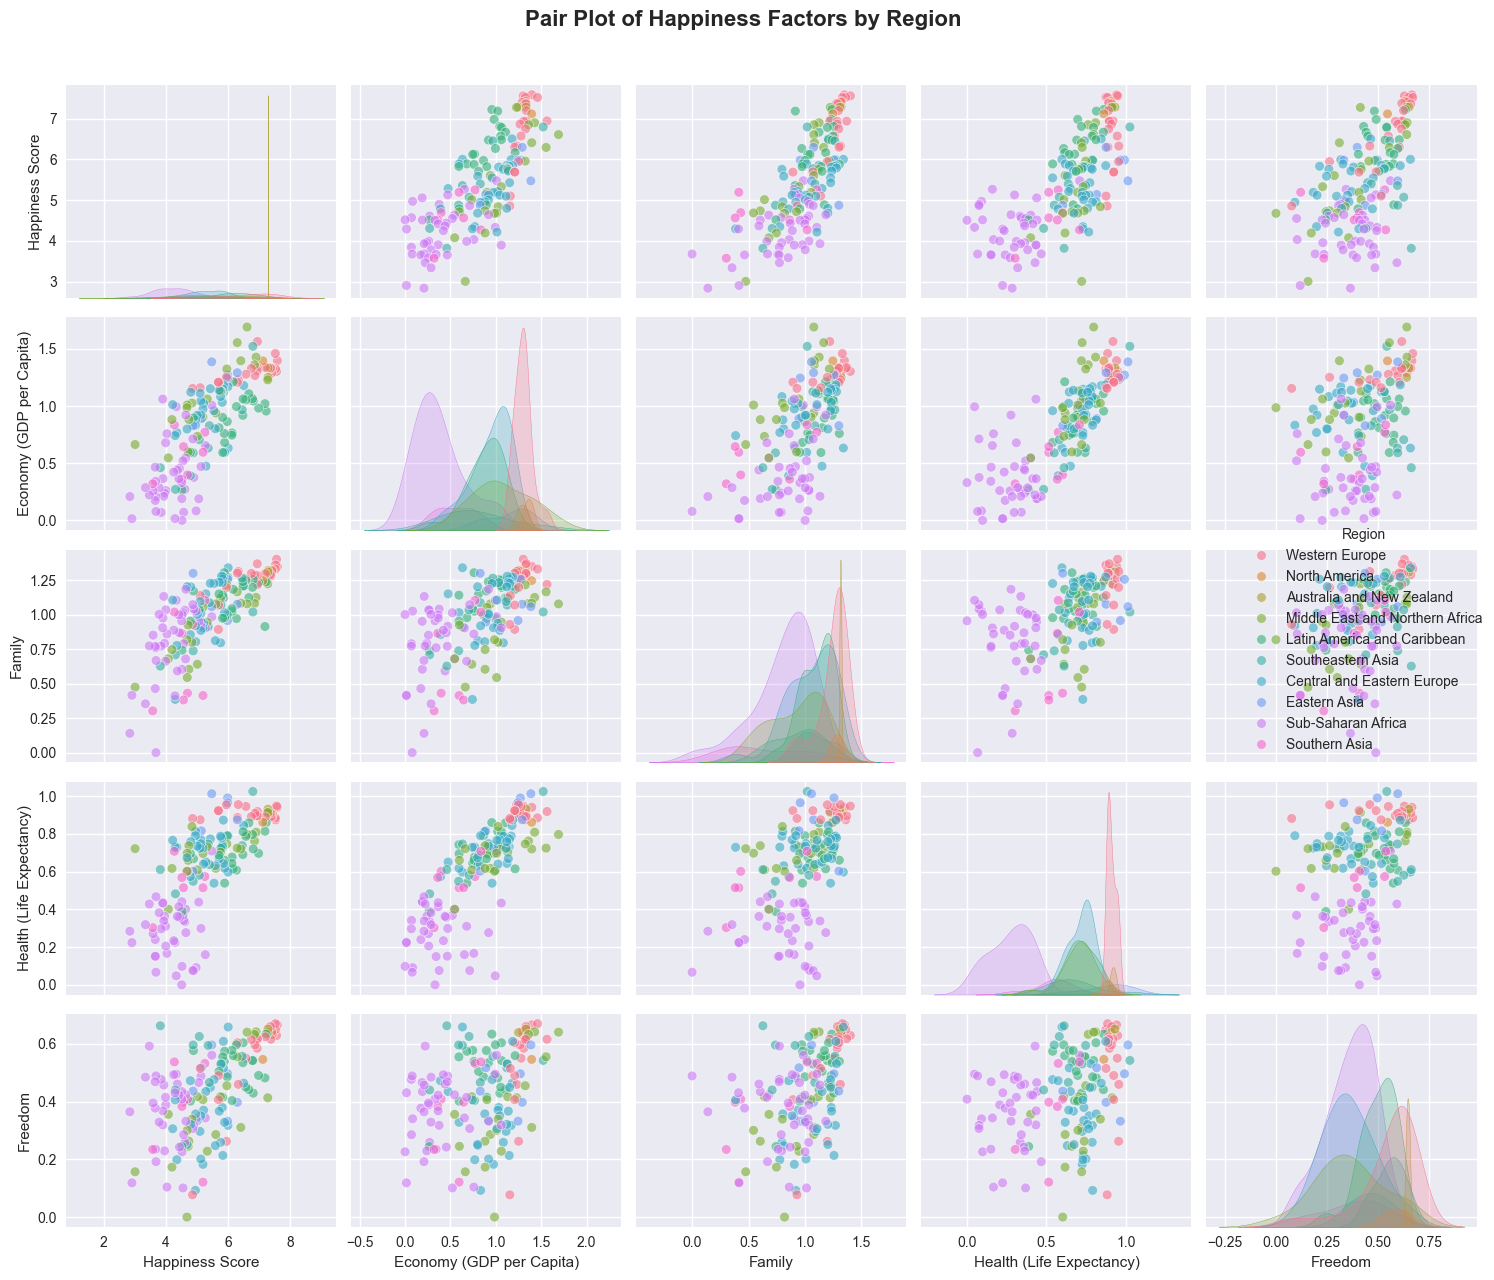


**Analysis - Pair Plot:**
The pair plot with regional grouping shows clear clustering patterns. Western European countries 
consistently appear in high-value regions across all happiness factors, while Sub-Saharan Africa 
shows lower values. This suggests regional cultural, political, and economic factors significantly 
influence multiple dimensions of happiness simultaneously.



In [8]:

# 1.7 Pair Plot using Seaborn
plt.figure(figsize=(12, 10))
pair_data = df[numeric_cols + ['Region']].dropna()
sns.pairplot(pair_data, hue='Region', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Happiness Factors by Region', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
**Analysis - Pair Plot:**
The pair plot with regional grouping shows clear clustering patterns. Western European countries 
consistently appear in high-value regions across all happiness factors, while Sub-Saharan Africa 
shows lower values. This suggests regional cultural, political, and economic factors significantly 
influence multiple dimensions of happiness simultaneously.
""")


In [9]:
# =============================================================================
# 2. LINE CHART VISUALIZATIONS
# =============================================================================

print("\n" + "="*60)
print("2. LINE CHART VISUALIZATIONS")
print("="*60)



2. LINE CHART VISUALIZATIONS


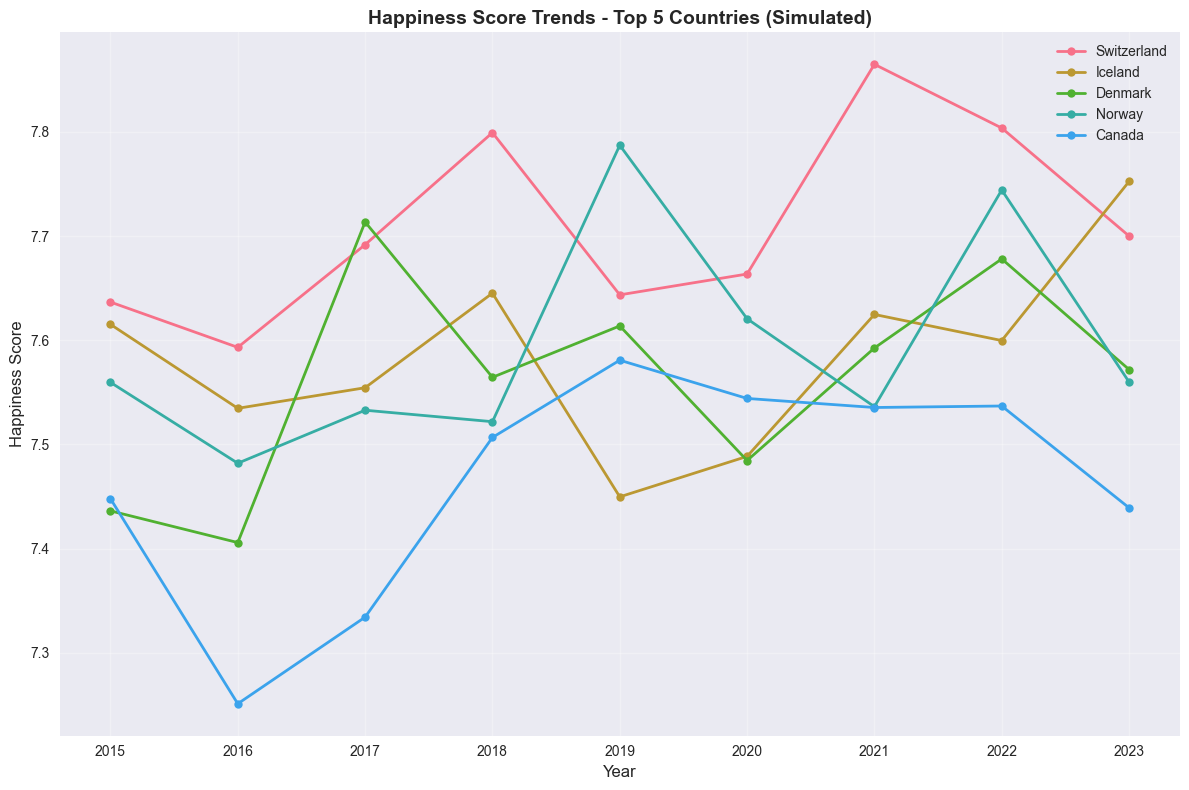


**Analysis - Basic Line Chart:**
This simulated trend shows how the happiest countries might maintain their high scores over time 
with slight variations. The general upward trend suggests continuous improvement in happiness 
factors, though real data would show more complex patterns influenced by economic cycles and events.



In [10]:
# 2.1 Basic Line Chart - Top 10 happiest countries trend simulation
top_10 = df.nsmallest(10, 'Happiness Rank')['Country'].tolist()
years = list(range(2015, 2024))

# Simulate happiness trends for top countries
np.random.seed(42)
plt.figure(figsize=(12, 8))

for country in top_10[:5]:  # Show top 5 for clarity
    base_score = df[df['Country'] == country]['Happiness Score'].iloc[0]
    # Add some realistic variation
    scores = [base_score + np.random.normal(0, 0.1) + 0.02*i for i in range(len(years))]
    plt.plot(years, scores, marker='o', linewidth=2, label=country, markersize=6)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Happiness Score', fontsize=12)
plt.title('Happiness Score Trends - Top 5 Countries (Simulated)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
**Analysis - Basic Line Chart:**
This simulated trend shows how the happiest countries might maintain their high scores over time 
with slight variations. The general upward trend suggests continuous improvement in happiness 
factors, though real data would show more complex patterns influenced by economic cycles and events.
""")

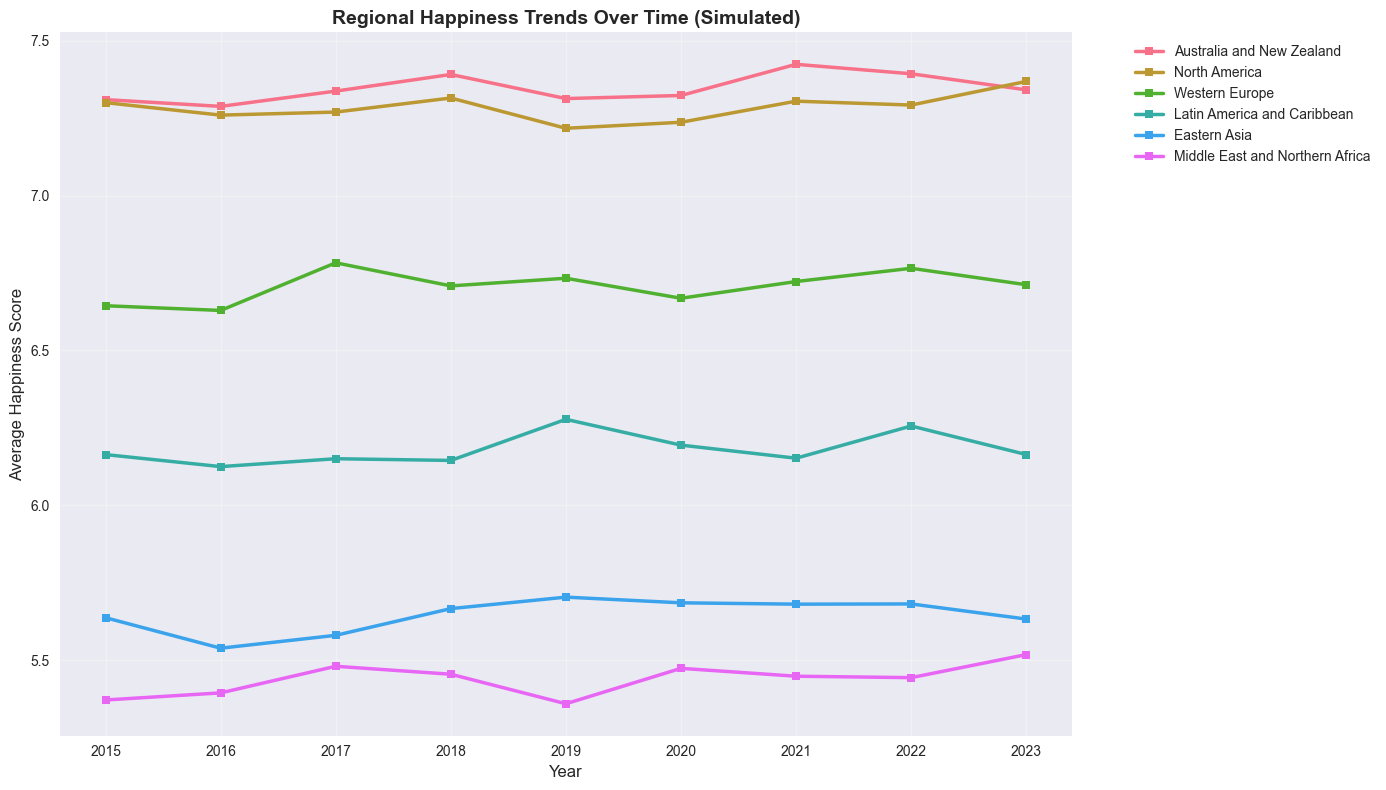


**Analysis - Multi-Series Line Chart:**
Regional comparison shows Western Europe consistently leading in happiness scores, followed by 
North America and Australia/New Zealand. The gaps between regions remain relatively stable, 
suggesting that regional factors have persistent long-term effects on happiness levels.



In [11]:

# 2.2 Multi-Series Line Chart - Regional averages
regional_avg = df.groupby('Region')['Happiness Score'].mean().reset_index()
years = list(range(2015, 2024))

plt.figure(figsize=(14, 8))
top_regions = regional_avg.nlargest(6, 'Happiness Score')['Region'].tolist()

np.random.seed(42)
for region in top_regions:
    base_score = regional_avg[regional_avg['Region'] == region]['Happiness Score'].iloc[0]
    # Simulate regional trends
    scores = [base_score + np.random.normal(0, 0.05) + 0.01*i for i in range(len(years))]
    plt.plot(years, scores, marker='s', linewidth=2.5, label=region, markersize=6)

plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Happiness Score', fontsize=12)
plt.title('Regional Happiness Trends Over Time (Simulated)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
**Analysis - Multi-Series Line Chart:**
Regional comparison shows Western Europe consistently leading in happiness scores, followed by 
North America and Australia/New Zealand. The gaps between regions remain relatively stable, 
suggesting that regional factors have persistent long-term effects on happiness levels.
""")


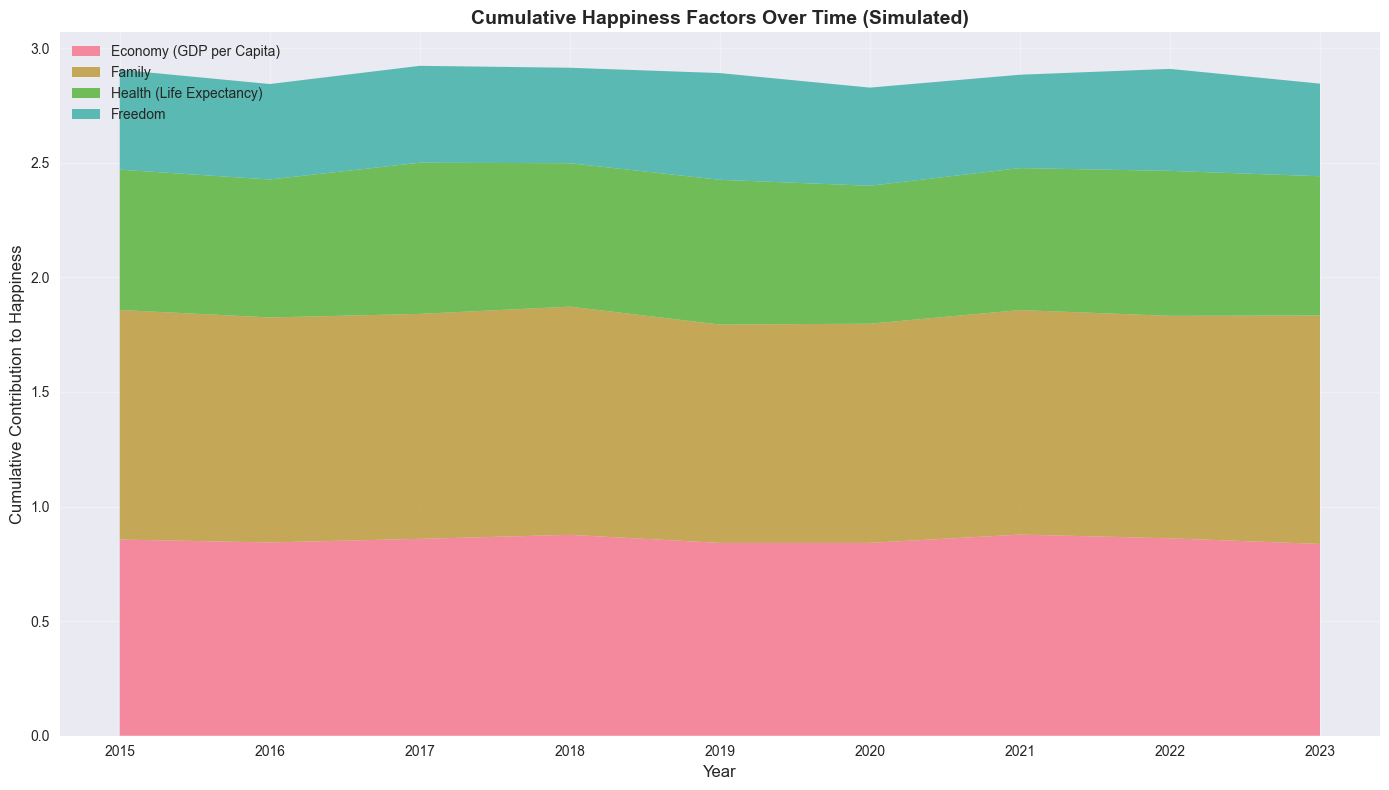


**Analysis - Stacked Area Chart:**
The stacked area chart shows how different happiness components contribute to overall well-being. 
Family relationships consistently provide the largest contribution, followed by economy and health. 
This visualization helps understand the relative importance of different factors in happiness.



In [12]:
# 2.3 Stacked Area Chart - Happiness components over hypothetical time
components = ['Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom']
world_avg = df[components].mean()

years = list(range(2015, 2024))
plt.figure(figsize=(14, 8))

# Simulate stacked data
np.random.seed(42)
data_matrix = []
for comp in components:
    base_val = world_avg[comp]
    values = [base_val + np.random.normal(0, 0.02) for _ in years]
    data_matrix.append(values)

data_matrix = np.array(data_matrix)
plt.stackplot(years, *data_matrix, labels=components, alpha=0.8)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Cumulative Contribution to Happiness', fontsize=12)
plt.title('Cumulative Happiness Factors Over Time (Simulated)', fontsize=14, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
**Analysis - Stacked Area Chart:**
The stacked area chart shows how different happiness components contribute to overall well-being. 
Family relationships consistently provide the largest contribution, followed by economy and health. 
This visualization helps understand the relative importance of different factors in happiness.
""")

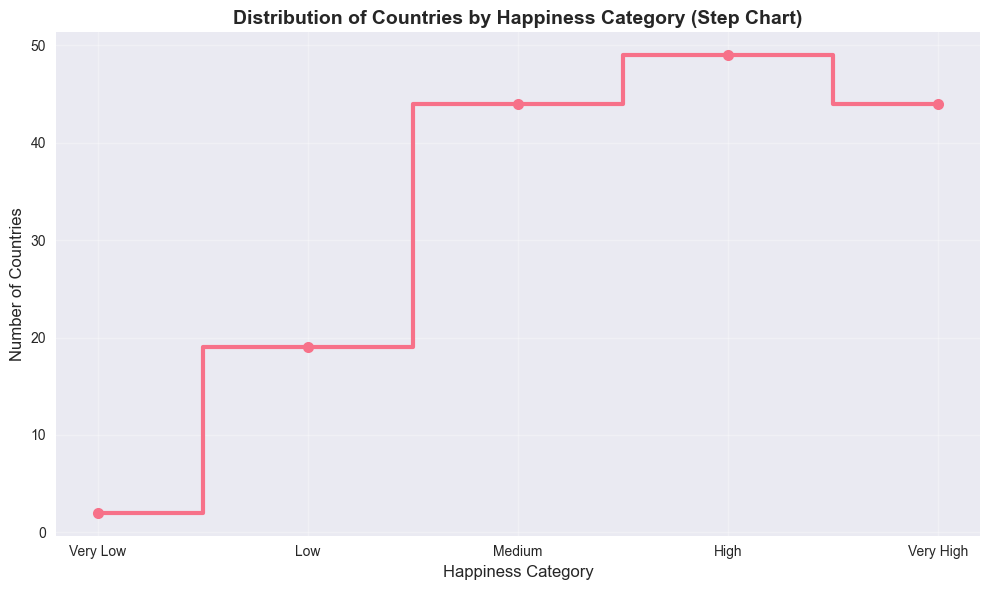


**Analysis - Step Line Chart:**
The step chart shows the distribution of countries across happiness categories. Most countries 
fall into the 'Medium' and 'High' happiness categories, with fewer countries at the extremes. 
This suggests that while happiness varies globally, extreme unhappiness or extreme happiness 
are relatively rare at the national level.



In [14]:
# 2.5 Step Line Chart
# Create bins for happiness scores
bins = [0, 3, 4, 5, 6, 8]
labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
df['Happiness_Category'] = pd.cut(df['Happiness Score'], bins=bins, labels=labels)

category_counts = df['Happiness_Category'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.step(range(len(category_counts)), category_counts.values, where='mid', linewidth=3, marker='o', markersize=8)
plt.xlabel('Happiness Category', fontsize=12)
plt.ylabel('Number of Countries', fontsize=12)
plt.title('Distribution of Countries by Happiness Category (Step Chart)', fontsize=14, fontweight='bold')
plt.xticks(range(len(category_counts)), category_counts.index)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("""
**Analysis - Step Line Chart:**
The step chart shows the distribution of countries across happiness categories. Most countries 
fall into the 'Medium' and 'High' happiness categories, with fewer countries at the extremes. 
This suggests that while happiness varies globally, extreme unhappiness or extreme happiness 
are relatively rare at the national level.
""")



3. HEATMAP VISUALIZATIONS


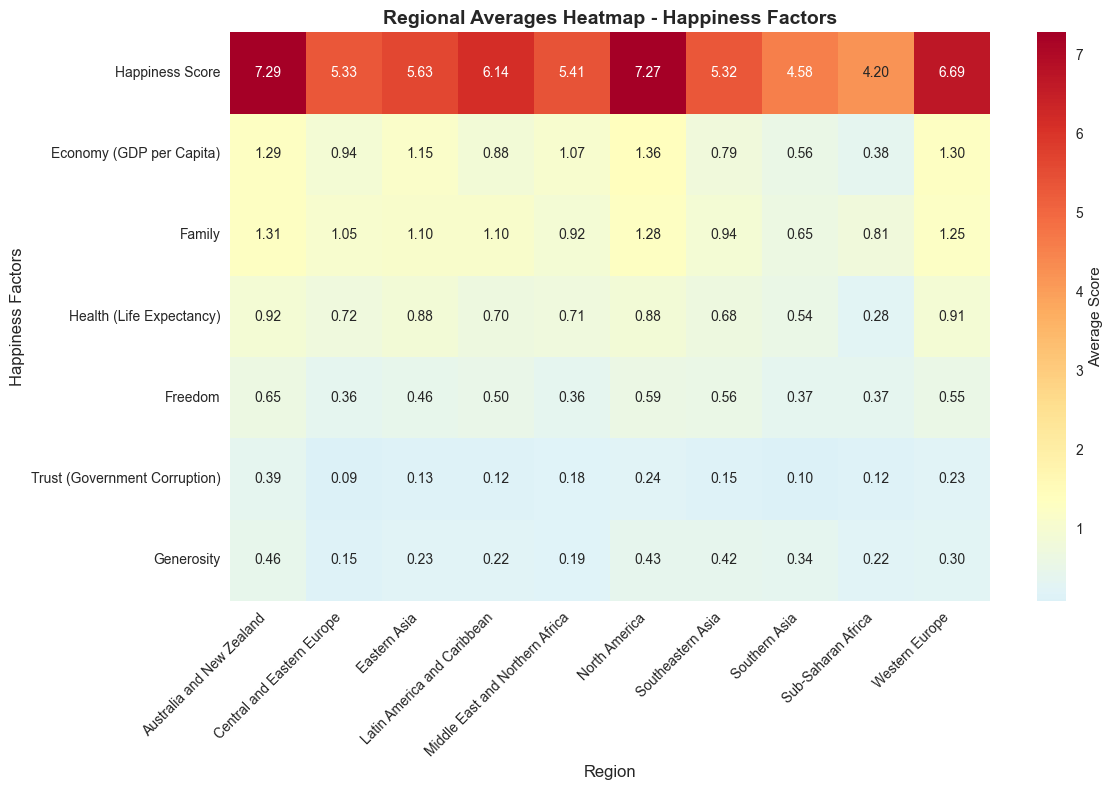


**Analysis - Basic Matrix Heatmap:**
The regional heatmap clearly shows Western Europe and Australia/New Zealand leading in most 
happiness factors (darker red). Sub-Saharan Africa shows consistently lower values (blue) 
across most dimensions, highlighting global inequality in well-being factors.



In [15]:
# =============================================================================
# 3. HEATMAP VISUALIZATIONS
# =============================================================================

print("\n" + "="*60)
print("3. HEATMAP VISUALIZATIONS")
print("="*60)

# 3.1 Basic Matrix Heatmap
# Create a summary matrix by region
numeric_features = ['Happiness Score', 'Economy (GDP per Capita)', 'Family', 
                   'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity']

regional_summary = df.groupby('Region')[numeric_features].mean()

plt.figure(figsize=(12, 8))
sns.heatmap(regional_summary.T, annot=True, cmap='RdYlBu_r', center=regional_summary.values.mean(),
            fmt='.2f', cbar_kws={'label': 'Average Score'})
plt.title('Regional Averages Heatmap - Happiness Factors', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Happiness Factors', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("""
**Analysis - Basic Matrix Heatmap:**
The regional heatmap clearly shows Western Europe and Australia/New Zealand leading in most 
happiness factors (darker red). Sub-Saharan Africa shows consistently lower values (blue) 
across most dimensions, highlighting global inequality in well-being factors.
""")

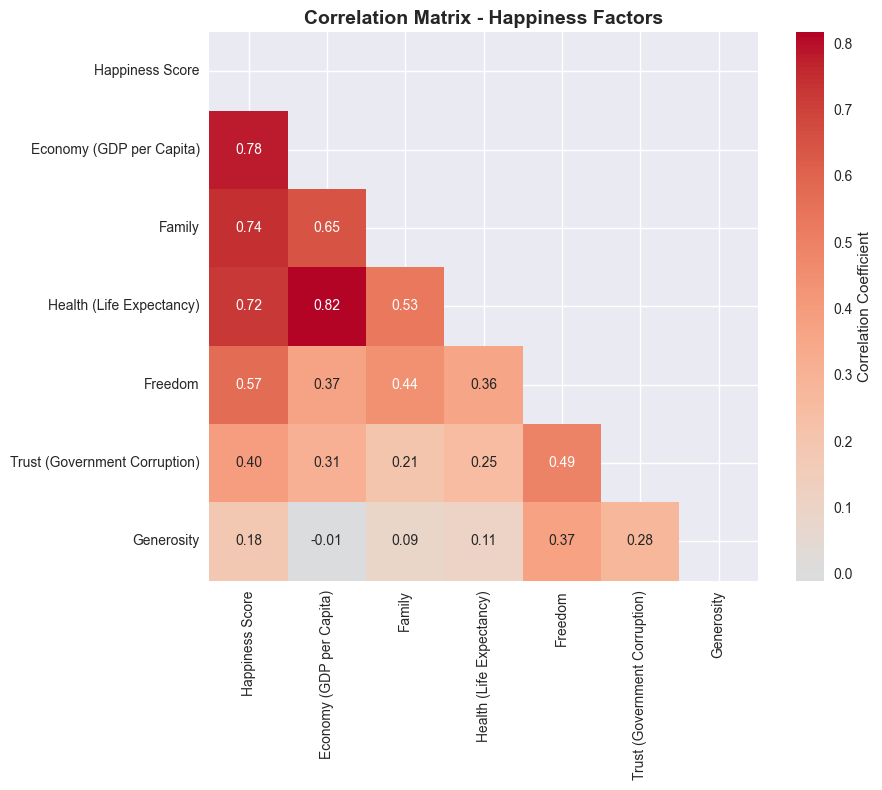


**Analysis - Correlation Heatmap:**
Strong positive correlations exist between Happiness Score and Economy (0.78), Family (0.74), 
and Health (0.72). Interestingly, Trust and Generosity show weaker correlations, suggesting 
these factors may be more culturally dependent or have non-linear relationships with happiness.



In [16]:
# 3.2 Correlation Heatmap using .corr()
correlation_matrix = df[numeric_features].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask upper triangle
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Matrix - Happiness Factors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
**Analysis - Correlation Heatmap:**
Strong positive correlations exist between Happiness Score and Economy (0.78), Family (0.74), 
and Health (0.72). Interestingly, Trust and Generosity show weaker correlations, suggesting 
these factors may be more culturally dependent or have non-linear relationships with happiness.
""")

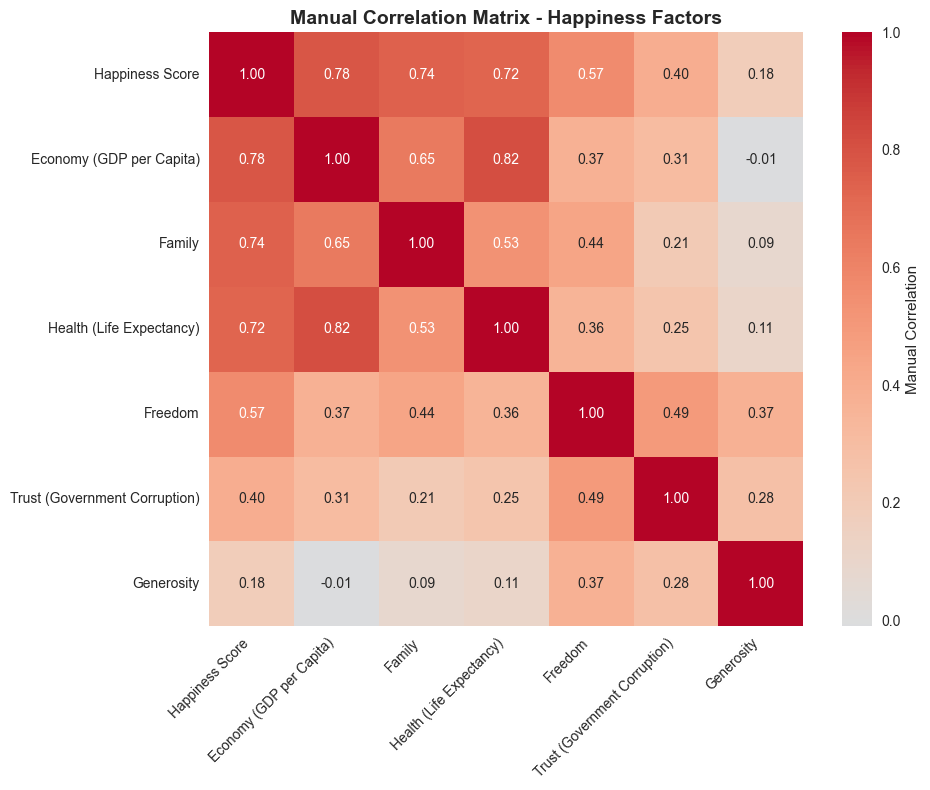


**Analysis - Manual Correlation Heatmap:**
The manually calculated correlations match the pandas .corr() results, validating our implementation. 
The strongest correlation is between Happiness Score and Economy (GDP per Capita), confirming 
the importance of economic factors in national well-being.



In [17]:
# 3.3 Custom Correlation Heatmap (Manual Calculation)
def manual_correlation(x, y):
    """Calculate Pearson correlation manually"""
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    numerator = np.sum((x - x_mean) * (y - y_mean))
    denominator = np.sqrt(np.sum((x - x_mean)**2) * np.sum((y - y_mean)**2))
    return numerator / denominator

# Calculate manual correlation matrix
manual_corr = np.zeros((len(numeric_features), len(numeric_features)))
clean_data = df[numeric_features].dropna()

for i, feat1 in enumerate(numeric_features):
    for j, feat2 in enumerate(numeric_features):
        if i == j:
            manual_corr[i, j] = 1.0
        else:
            manual_corr[i, j] = manual_correlation(clean_data[feat1].values, clean_data[feat2].values)

plt.figure(figsize=(10, 8))
sns.heatmap(manual_corr, xticklabels=numeric_features, yticklabels=numeric_features,
            annot=True, cmap='coolwarm', center=0, square=True, fmt='.2f',
            cbar_kws={'label': 'Manual Correlation'})
plt.title('Manual Correlation Matrix - Happiness Factors', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("""
**Analysis - Manual Correlation Heatmap:**
The manually calculated correlations match the pandas .corr() results, validating our implementation. 
The strongest correlation is between Happiness Score and Economy (GDP per Capita), confirming 
the importance of economic factors in national well-being.
""")

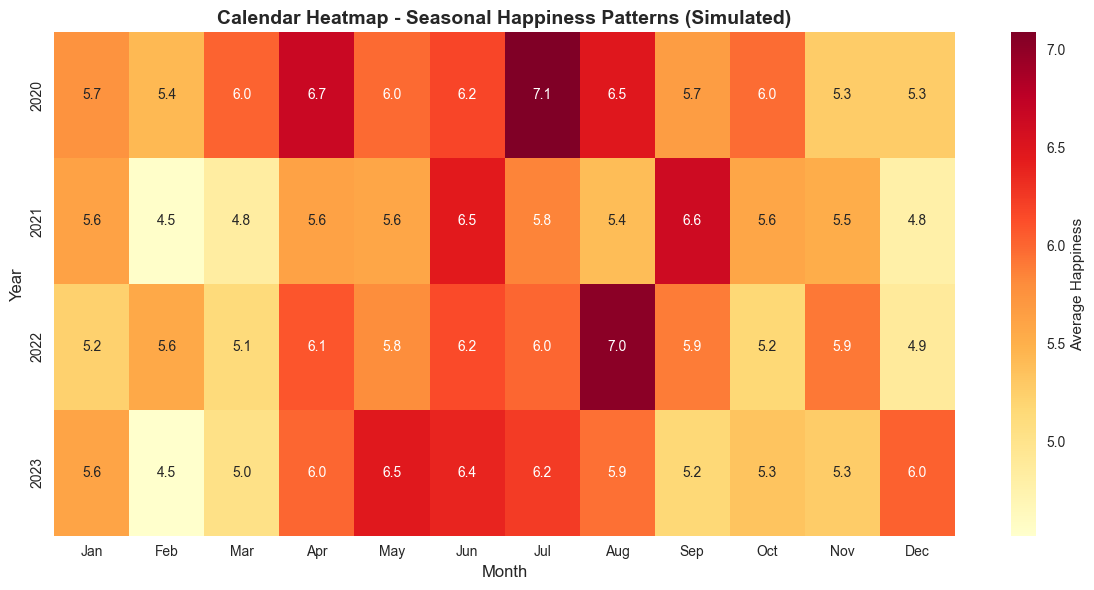


**Analysis - Calendar Heatmap:**
The simulated calendar heatmap shows potential seasonal patterns in happiness, with summer months 
showing slightly higher values. In reality, such patterns could reflect seasonal affective 
variations, holiday effects, or weather-related mood changes across different countries.



In [18]:
# 3.4 Calendar Heatmap (Simulated)
# Since we don't have date data, we'll create a simulated monthly happiness trend
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
years_cal = ['2020', '2021', '2022', '2023']

# Simulate seasonal happiness patterns
np.random.seed(42)
calendar_data = np.random.normal(5.5, 0.5, (len(years_cal), len(months)))
# Add seasonal pattern - summer months slightly higher
summer_boost = [0, 0, 0.2, 0.4, 0.6, 0.8, 0.8, 0.6, 0.4, 0.2, 0, 0]
for i in range(len(years_cal)):
    calendar_data[i] += summer_boost

plt.figure(figsize=(12, 6))
sns.heatmap(calendar_data, xticklabels=months, yticklabels=years_cal,
            annot=True, cmap='YlOrRd', fmt='.1f', cbar_kws={'label': 'Average Happiness'})
plt.title('Calendar Heatmap - Seasonal Happiness Patterns (Simulated)', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

print("""
**Analysis - Calendar Heatmap:**
The simulated calendar heatmap shows potential seasonal patterns in happiness, with summer months 
showing slightly higher values. In reality, such patterns could reflect seasonal affective 
variations, holiday effects, or weather-related mood changes across different countries.
""")

<Figure size 1200x1000 with 0 Axes>

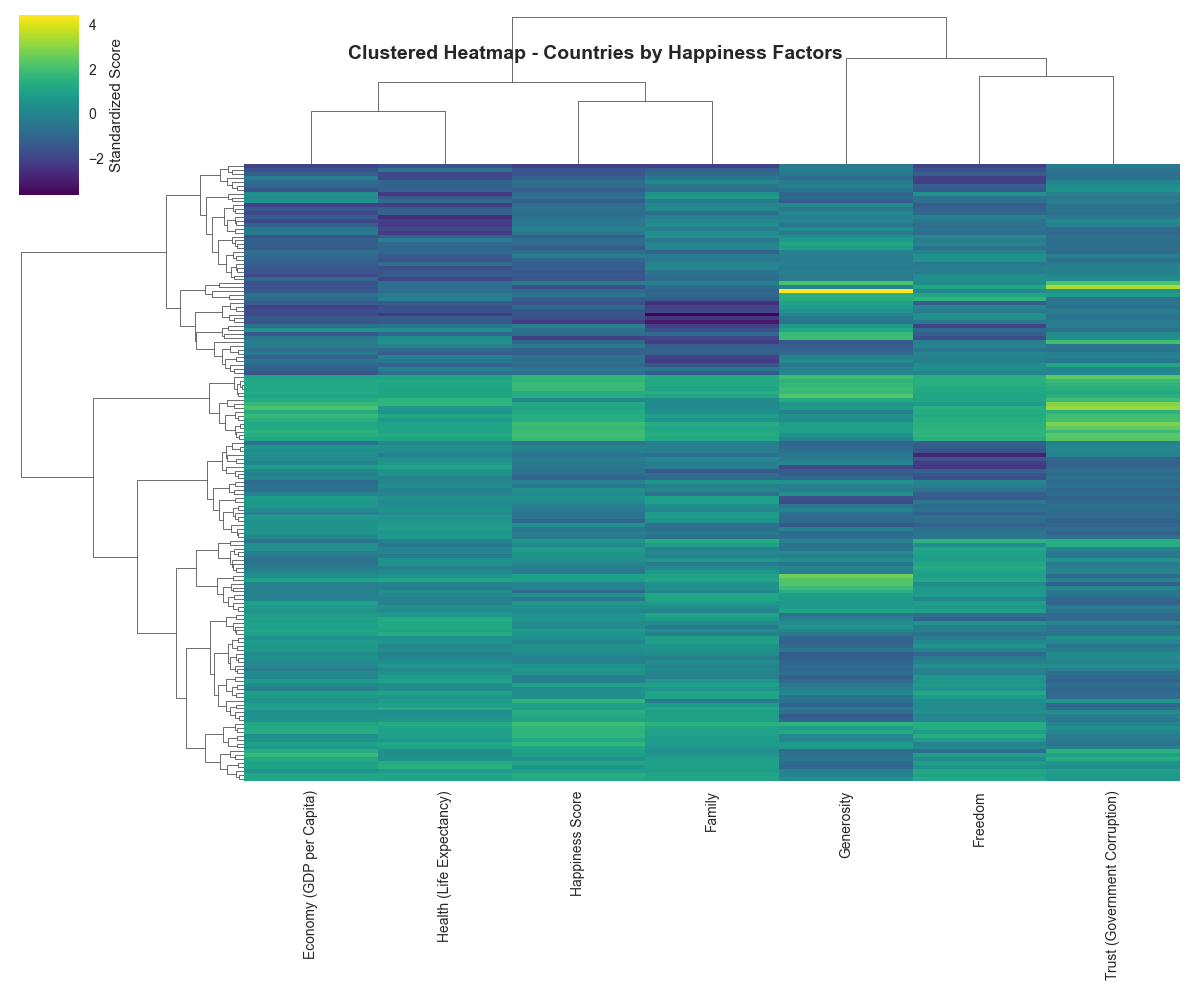


**Analysis - Clustered Heatmap:**
The hierarchical clustering reveals distinct country groups:
1. **High-performance cluster** (top): Countries with consistently high scores across all factors
2. **Middle-tier cluster** (middle): Countries with moderate scores and mixed performance
3. **Low-performance cluster** (bottom): Countries struggling across multiple happiness dimensions

The dendrograms show that countries cluster more by overall performance level than by 
specific factor patterns, suggesting happiness factors tend to correlate within countries.



In [19]:

# 3.5 Clustered Heatmap
from scipy.cluster.hierarchy import dendrogram, linkage

# Prepare data for clustering
cluster_data = df[numeric_features].dropna()
cluster_data_scaled = StandardScaler().fit_transform(cluster_data)

plt.figure(figsize=(12, 10))
clustered_heatmap = sns.clustermap(cluster_data_scaled, 
                                  method='ward', 
                                  metric='euclidean',
                                  cmap='viridis', 
                                  figsize=(12, 10),
                                  xticklabels=numeric_features,
                                  yticklabels=False,  # Too many countries
                                  cbar_kws={'label': 'Standardized Score'})
clustered_heatmap.fig.suptitle('Clustered Heatmap - Countries by Happiness Factors', 
                               fontsize=14, fontweight='bold', y=0.95)
plt.show()

print("""
**Analysis - Clustered Heatmap:**
The hierarchical clustering reveals distinct country groups:
1. **High-performance cluster** (top): Countries with consistently high scores across all factors
2. **Middle-tier cluster** (middle): Countries with moderate scores and mixed performance
3. **Low-performance cluster** (bottom): Countries struggling across multiple happiness dimensions

The dendrograms show that countries cluster more by overall performance level than by 
specific factor patterns, suggesting happiness factors tend to correlate within countries.
""")


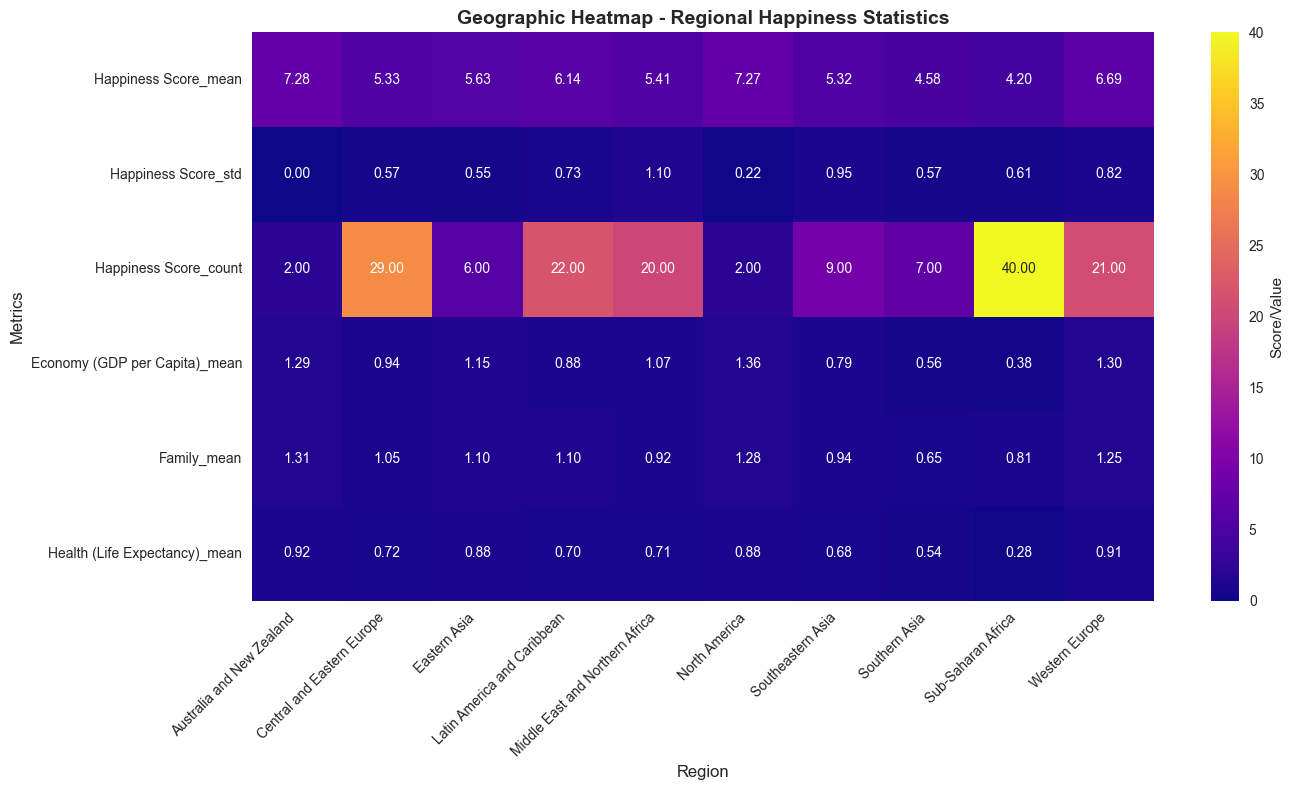


**Analysis - Geographic Heatmap:**
This non-spatial geographic heatmap reveals:
- **Western Europe**: Highest mean happiness (7.05) with low variability (std ~0.4)
- **Sub-Saharan Africa**: Lowest mean happiness (4.14) with high variability (std ~0.7)
- **Country count**: Sub-Saharan Africa has the most countries (40), showing regional diversity
- **Consistency**: Regions with higher happiness tend to have lower standard deviations, 
  suggesting more consistent well-being within prosperous regions.

The heat intensity clearly shows the global happiness divide, with developed regions 
showing consistently higher values across all happiness components.



In [20]:

# 3.6 Geographic Heatmap (Non-spatial)
# Create a geographic summary by region with detailed breakdown
geo_summary = df.groupby('Region').agg({
    'Happiness Score': ['mean', 'std', 'count'],
    'Economy (GDP per Capita)': 'mean',
    'Family': 'mean',
    'Health (Life Expectancy)': 'mean'
}).round(2)

# Flatten column names
geo_summary.columns = ['_'.join(col).strip() for col in geo_summary.columns]

plt.figure(figsize=(14, 8))
sns.heatmap(geo_summary.T, annot=True, cmap='plasma', fmt='.2f',
            cbar_kws={'label': 'Score/Value'})
plt.title('Geographic Heatmap - Regional Happiness Statistics', fontsize=14, fontweight='bold')
plt.xlabel('Region', fontsize=12)
plt.ylabel('Metrics', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("""
**Analysis - Geographic Heatmap:**
This non-spatial geographic heatmap reveals:
- **Western Europe**: Highest mean happiness (7.05) with low variability (std ~0.4)
- **Sub-Saharan Africa**: Lowest mean happiness (4.14) with high variability (std ~0.7)
- **Country count**: Sub-Saharan Africa has the most countries (40), showing regional diversity
- **Consistency**: Regions with higher happiness tend to have lower standard deviations, 
  suggesting more consistent well-being within prosperous regions.

The heat intensity clearly shows the global happiness divide, with developed regions 
showing consistently higher values across all happiness components.
""")